#Prediction using Machine Learning

## Project Objective
This project compares three machine learning classification algorithms for breast cancer prediction:
- Logistic Regression
- Random Forest
- Support Vector Machine (SVM)

### Evaluation Metrics
Accuracy, Precision, Recall/Sensitivity, Specificity, F1-Score, and ROC-AUC.



## Phase A — Data Preprocessing

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="Target")

print("Dataset Shape:", X.shape)
print("\nTarget Classes:")
print(y.value_counts().sort_index())
print("\nClass Names:", list(data.target_names))

Dataset Shape: (569, 30)

Target Classes:
Target
0    212
1    357
Name: count, dtype: int64

Class Names: [np.str_('malignant'), np.str_('benign')]


In [2]:
# Basic dataset information
print(X.info())
print("\nMissing values:", X.isnull().sum().sum())
print("Duplicate rows:", X.duplicated().sum())

display(X.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


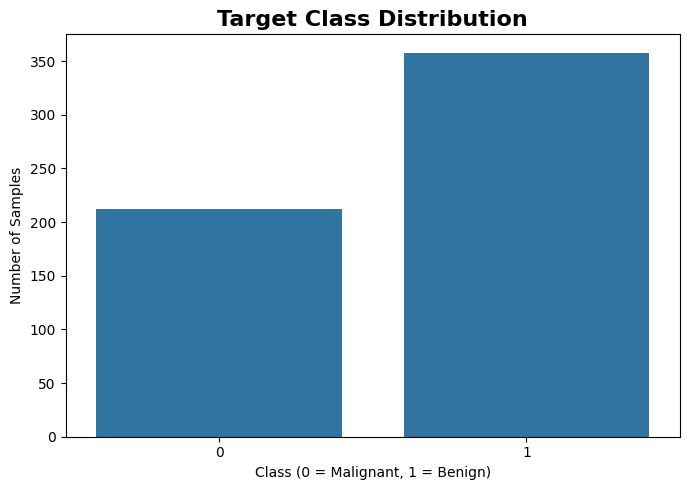

In [3]:
# Class distribution
plt.figure(figsize=(7, 5))
sns.countplot(x=y)
plt.title("Target Class Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Class (0 = Malignant, 1 = Benign)")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()

In [4]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


## Phase B — Model Implementation

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),
    "SVM": SVC(probability=True, random_state=42)
}

trained_models = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    trained_models[name] = model
    predictions[name] = y_pred

    print(f"{name}: Training completed")

Logistic Regression: Training completed
Random Forest: Training completed
SVM: Training completed


## Phase C — Model Evaluation

In [6]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

evaluation_results = []

for name, model in trained_models.items():
    y_pred = predictions[name]

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    specificity = tn / (tn + fp)
    f1 = f1_score(y_test, y_pred)

    y_score = model.predict_proba(X_test_scaled)[:, 1]
    roc_auc = roc_auc_score(y_test, y_score)

    evaluation_results.append({
        "Algorithm": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall/Sensitivity": recall,
        "Specificity": specificity,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    })

results_df = pd.DataFrame(evaluation_results)

display(results_df.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall/Sensitivity": "{:.4f}",
    "Specificity": "{:.4f}",
    "F1-Score": "{:.4f}",
    "ROC-AUC": "{:.4f}"
}))

,Algorithm,Accuracy,Precision,Recall/Sensitivity,Specificity,F1-Score,ROC-AUC
0,Logistic Regression,0.9825,0.9861,0.9861,0.9762,0.9861,0.9954
1,Random Forest,0.9561,0.9589,0.9722,0.9286,0.9655,0.9932
2,SVM,0.9825,0.9861,0.9861,0.9762,0.9861,0.9950


## Confusion Matrices

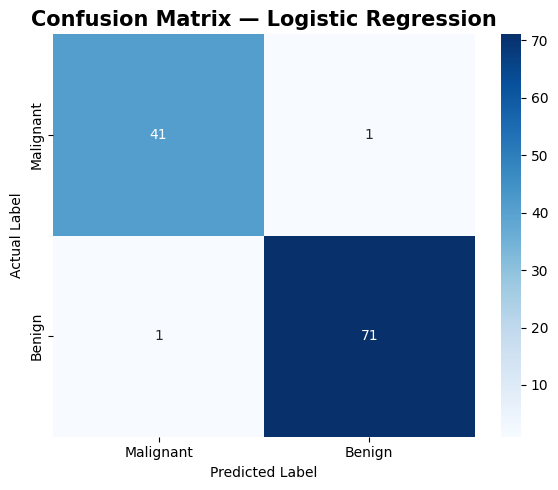

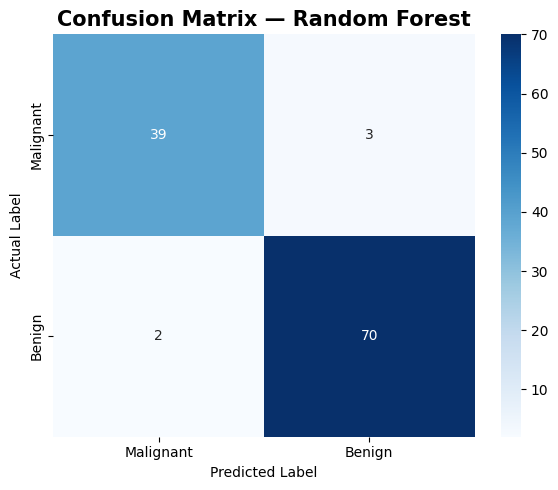

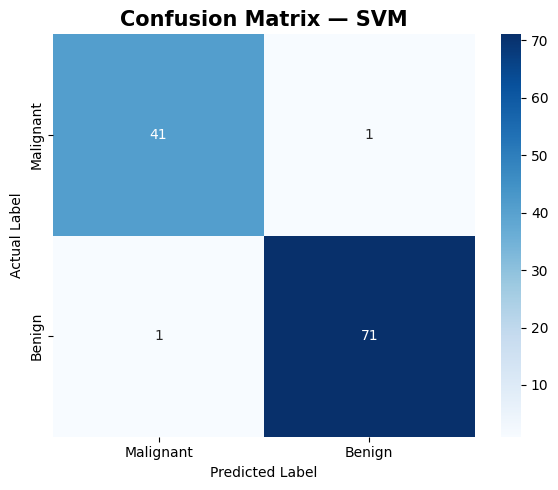

In [7]:
for name, y_pred in predictions.items():
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Malignant", "Benign"],
        yticklabels=["Malignant", "Benign"]
    )

    plt.title(f"Confusion Matrix — {name}", fontsize=15, fontweight="bold")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.tight_layout()
    plt.show()

## Performance Comparison

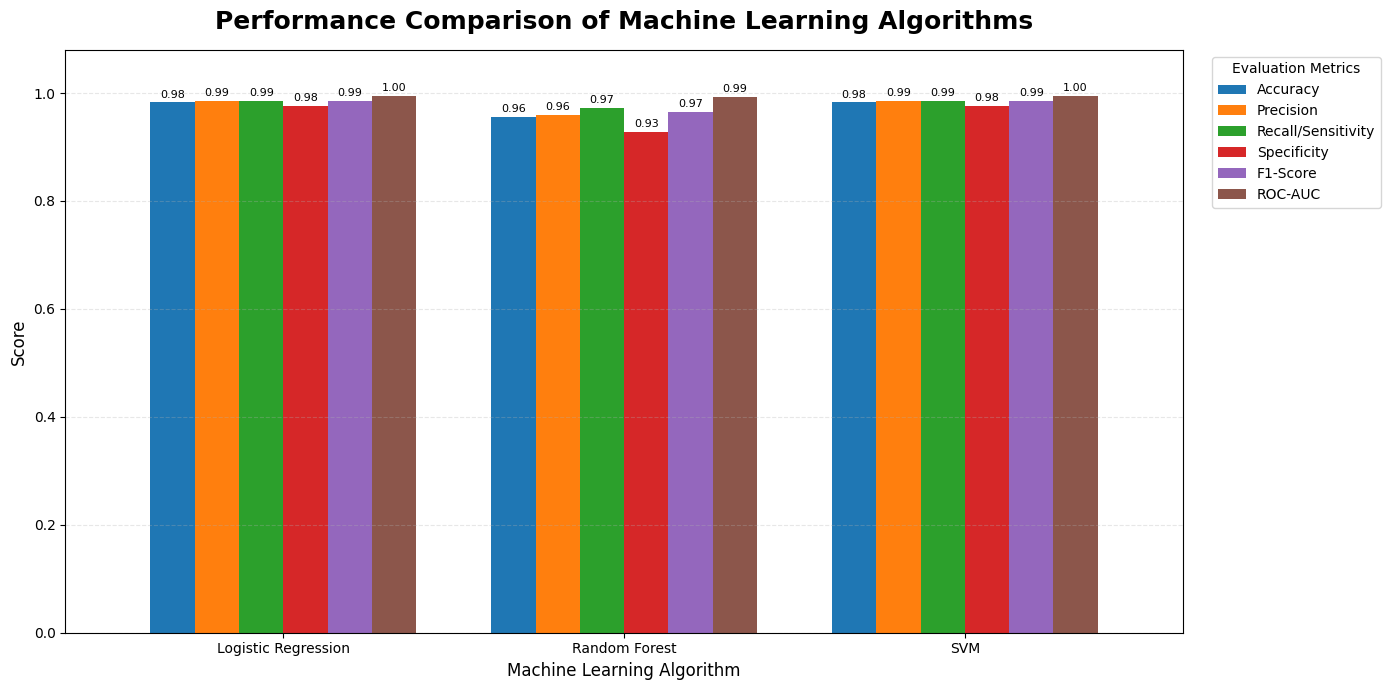

In [8]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall/Sensitivity",
    "Specificity",
    "F1-Score",
    "ROC-AUC"
]

ax = results_df.set_index("Algorithm")[metrics].plot(
    kind="bar",
    figsize=(14, 7),
    width=0.78
)

plt.title(
    "Performance Comparison of Machine Learning Algorithms",
    fontsize=18,
    fontweight="bold",
    pad=15
)
plt.xlabel("Machine Learning Algorithm", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.ylim(0, 1.08)
plt.xticks(rotation=0)
plt.legend(title="Evaluation Metrics", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(axis="y", linestyle="--", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=8, padding=2)

plt.tight_layout()
plt.show()

## ROC Curve Comparison

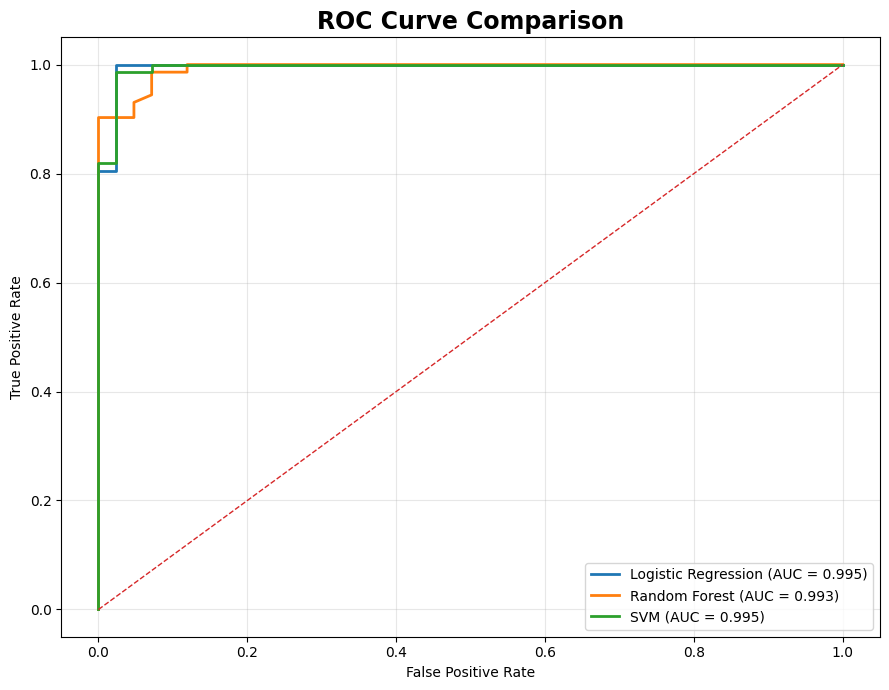

In [9]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(9, 7))

for name, model in trained_models.items():
    y_score = model.predict_proba(X_test_scaled)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr, tpr,
        linewidth=2,
        label=f"{name} (AUC = {roc_auc:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)

plt.title("ROC Curve Comparison", fontsize=17, fontweight="bold")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Best Model

In [10]:
best_model = results_df.loc[
    results_df["F1-Score"].idxmax(), "Algorithm"
]

print("Best model based on F1-Score:", best_model)

print("\nFinal Results:")
display(results_df.sort_values("F1-Score", ascending=False).reset_index(drop=True))

Best model based on F1-Score: Logistic Regression

Final Results:


,Algorithm,Accuracy,Precision,Recall/Sensitivity,Specificity,F1-Score,ROC-AUC
0,Logistic Regression,0.982456,0.986111,0.986111,0.976190,0.986111,0.995370
1,SVM,0.982456,0.986111,0.986111,0.976190,0.986111,0.995040
2,Random Forest,0.956140,0.958904,0.972222,0.928571,0.965517,0.993221


## Discussion

The three classification algorithms were trained and evaluated using the same train-test split and standardized features. Accuracy, Precision, Recall/Sensitivity, Specificity, F1-Score, and ROC-AUC were used to compare their performance.

For disease prediction, Recall/Sensitivity is particularly important because missing a positive disease case can be more serious than generating a false positive. Therefore, the final model should not be selected using Accuracy alone.

## Conclusion

This project demonstrates a complete machine-learning workflow for breast cancer classification, including data preprocessing, model implementation, evaluation, confusion-matrix analysis, and ROC-curve comparison.

The model with the strongest overall evaluation metrics can be considered the best-performing model for this experimental dataset. However, model performance on a public dataset does not establish clinical effectiveness, and real-world medical deployment would require additional validation and clinical assessment.